# Skin Cancer Detection — phân loại tổn thương da (HAM10000)

Phân loại tổn thương da từ metadata bệnh nhân (HAM10000, ISIC) thay vì ảnh thô.

- **Binary**: lành tính vs cần lưu ý.
- **Multi-class**: 7 loại — `nv, mel, bkl, bcc, akiec, vasc, df`.

Pipeline: tiền xử lý → SVM → đánh giá → cross-validation & tuning → so sánh mô hình.


## 1. Import

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Đọc dữ liệu

In [2]:
import os
DATA_PATH = "../data/HAM10000_metadata.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "data/HAM10000_metadata.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (10124, 8)


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10124 entries, 0 to 10123
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10124 non-null  object 
 1   image_id      10124 non-null  object 
 2   dx            10124 non-null  object 
 3   dx_type       10124 non-null  object 
 4   age           10067 non-null  float64
 5   sex           10124 non-null  object 
 6   localization  10124 non-null  object 
 7   dataset       10124 non-null  object 
dtypes: float64(1), object(7)
memory usage: 632.9+ KB


## 3. EDA

In [4]:
# Missing values
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dataset          0
dtype: int64

dx
nv         6705
mel        1113
bkl        1099
bcc         514
akiec       327
vasc        142
df          115
healthy     109
Name: count, dtype: int64


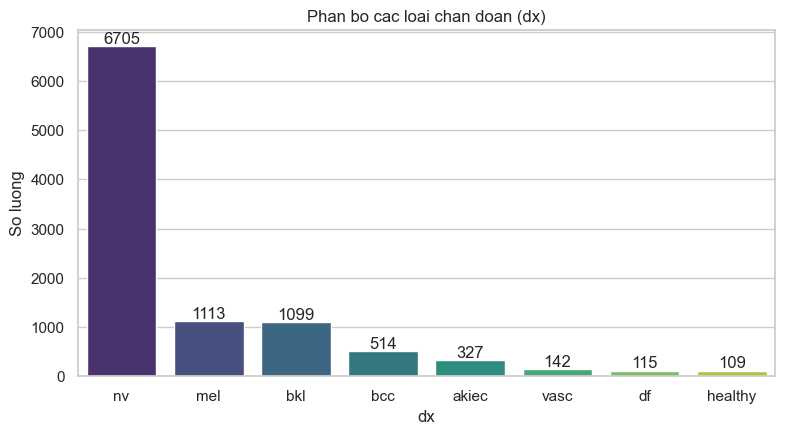

In [5]:
# Phan bo target
print(df['dx'].value_counts())
plt.figure(figsize=(9, 4.5))
order = df['dx'].value_counts()
sns.barplot(x=order.index, y=order.values, palette="viridis")
for i, v in enumerate(order.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.title("Phan bo cac loai chan doan (dx)")
plt.ylabel("So luong")
plt.show()

`nv` chiếm ~66% — dữ liệu lệch nặng. Lớp `healthy` (109 mẫu) không nằm trong 7 loại
chuẩn nên loại bỏ. Với dữ liệu lệch, accuracy không đủ; theo dõi thêm macro-F1.

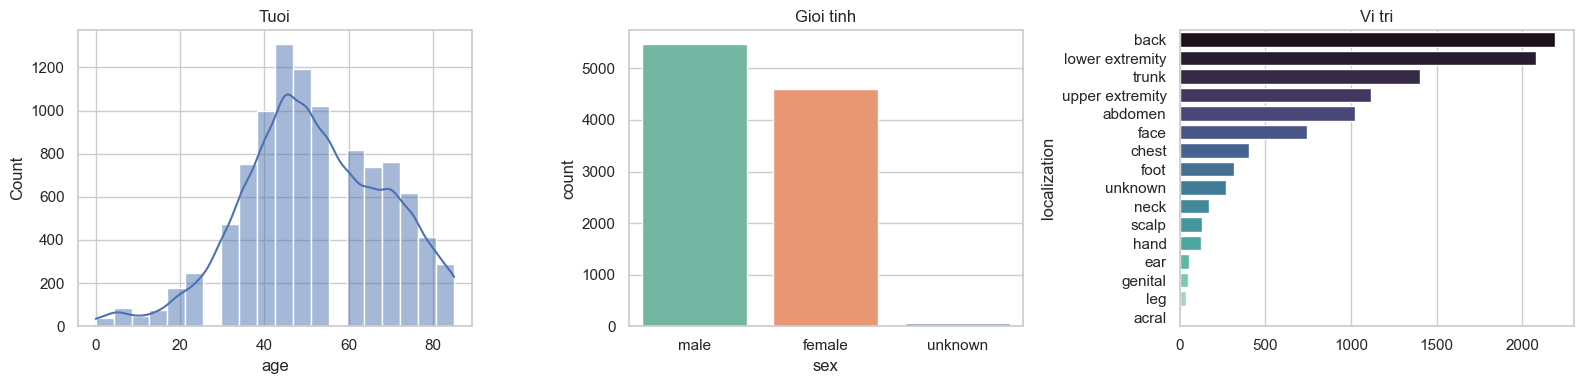

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['age'].dropna(), bins=20, kde=True, ax=ax[0]); ax[0].set_title("Tuoi")
sns.countplot(x='sex', data=df, ax=ax[1], palette="Set2"); ax[1].set_title("Gioi tinh")
loc = df['localization'].value_counts()
sns.barplot(y=loc.index, x=loc.values, ax=ax[2], palette="mako"); ax[2].set_title("Vi tri")
plt.tight_layout(); plt.show()

### 3.1. Chọn feature

`dx_type` (cách xác nhận chẩn đoán) tương quan mạnh với `dx` và không có ở thời điểm
dự đoán → loại để tránh leakage. Bỏ luôn `dataset`, `lesion_id`, `image_id`. Feature
dùng: `age`, `sex`, `localization`.

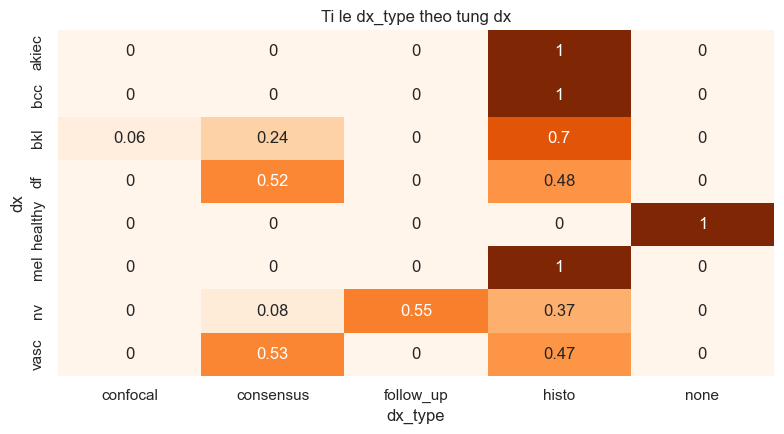

In [7]:
ct = pd.crosstab(df['dx'], df['dx_type'], normalize='index').round(2)
plt.figure(figsize=(8, 4.5))
sns.heatmap(ct, annot=True, cmap="Oranges", cbar=False)
plt.title("Ti le dx_type theo tung dx")
plt.tight_layout(); plt.show()

## 4. Tiền xử lý

In [8]:
df = df[df['dx'] != 'healthy'].copy().reset_index(drop=True)

# 1 = nhom can luu y, 0 = lanh tinh
MALIGNANT = {'mel', 'bcc', 'akiec', 'vasc'}
df['label_binary'] = df['dx'].isin(MALIGNANT).astype(int)

# Map ma viet tat -> ten day du
dx_dict = {
    'nv': 'Melanocytic nevi', 'mel': 'Melanoma', 'bkl': 'Benign keratosis',
    'bcc': 'Basal cell carcinoma', 'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions', 'df': 'Dermatofibroma'}
df['diagnosis'] = df['dx'].map(dx_dict)

df['label_binary'].value_counts()

label_binary
0    7919
1    2096
Name: count, dtype: int64

In [9]:
FEATURES = ['age', 'sex', 'localization']

def build_features(frame, fit_objs=None):
    """Impute -> encode -> scale. fit_objs=None: fit (train); nguoc lai: transform (test)."""
    X = frame[FEATURES].copy()
    if fit_objs is None:
        imp = SimpleImputer(strategy='median')
        X['age'] = imp.fit_transform(X[['age']])
        encs = {}
        for c in ['sex', 'localization']:
            e = LabelEncoder()
            X[c] = e.fit_transform(X[c].astype(str))
            encs[c] = e
        sc = StandardScaler()
        return sc.fit_transform(X), {'imp': imp, 'encs': encs, 'sc': sc}
    X['age'] = fit_objs['imp'].transform(X[['age']])
    for c, e in fit_objs['encs'].items():
        X[c] = X[c].astype(str).map(lambda v: v if v in set(e.classes_) else e.classes_[0])
        X[c] = e.transform(X[c])
    return fit_objs['sc'].transform(X), fit_objs

## 5. Binary Classification (SVM)

In [10]:
tr, te = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE,
                          stratify=df['label_binary'])
Xtr, objs = build_features(tr)
Xte, _ = build_features(te, objs)
ytr, yte = tr['label_binary'].values, te['label_binary'].values
print("Train:", Xtr.shape, "Test:", Xte.shape)

Train: (8012, 3) Test: (2003, 3)


In [11]:
# Baseline (khong can bang) vs class_weight balanced
for name, m in [("default", SVC(kernel='rbf', random_state=RANDOM_STATE)),
                ("balanced", SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE))]:
    m.fit(Xtr, ytr)
    p = m.predict(Xte)
    print(f"{name:9s} acc={accuracy_score(yte,p):.3f} macro-F1={f1_score(yte,p,average='macro'):.3f}")

default   acc=0.791 macro-F1=0.442


balanced  acc=0.693 macro-F1=0.635


SVM mặc định cho accuracy cao hơn nhưng macro-F1 thấp do thiên về lớp đa số.
`class_weight='balanced'` đổi lại recall cao hơn ở nhóm cần lưu ý — ưu tiên đúng cho
bài toán sàng lọc. Dùng bản balanced cho các bước sau.

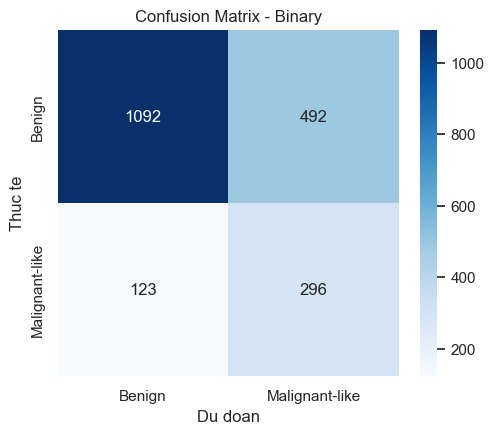

                precision    recall  f1-score   support

        Benign      0.899     0.689     0.780      1584
Malignant-like      0.376     0.706     0.490       419

      accuracy                          0.693      2003
     macro avg      0.637     0.698     0.635      2003
  weighted avg      0.789     0.693     0.720      2003



In [12]:
svm_bin = SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE).fit(Xtr, ytr)
y_pred_bin = svm_bin.predict(Xte)

cm = confusion_matrix(yte, y_pred_bin)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant-like'],
            yticklabels=['Benign', 'Malignant-like'])
plt.xlabel('Du doan'); plt.ylabel('Thuc te'); plt.title('Confusion Matrix - Binary'); plt.show()

print(classification_report(yte, y_pred_bin,
      target_names=['Benign', 'Malignant-like'], digits=3))

## 6. Multi-class Classification (7 lớp, SVM)

In [13]:
le = LabelEncoder()
df['label_multi'] = le.fit_transform(df['dx'])
class_names = list(le.classes_)

tr, te = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE,
                          stratify=df['label_multi'])
Xtr, objs = build_features(tr)
Xte, _ = build_features(te, objs)
ytr, yte = tr['label_multi'].values, te['label_multi'].values

svm_multi = SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE).fit(Xtr, ytr)
y_pred_multi = svm_multi.predict(Xte)
print("acc:", round(accuracy_score(yte, y_pred_multi), 3),
      "macro-F1:", round(f1_score(yte, y_pred_multi, average='macro'), 3))

acc: 0.307 macro-F1: 0.173


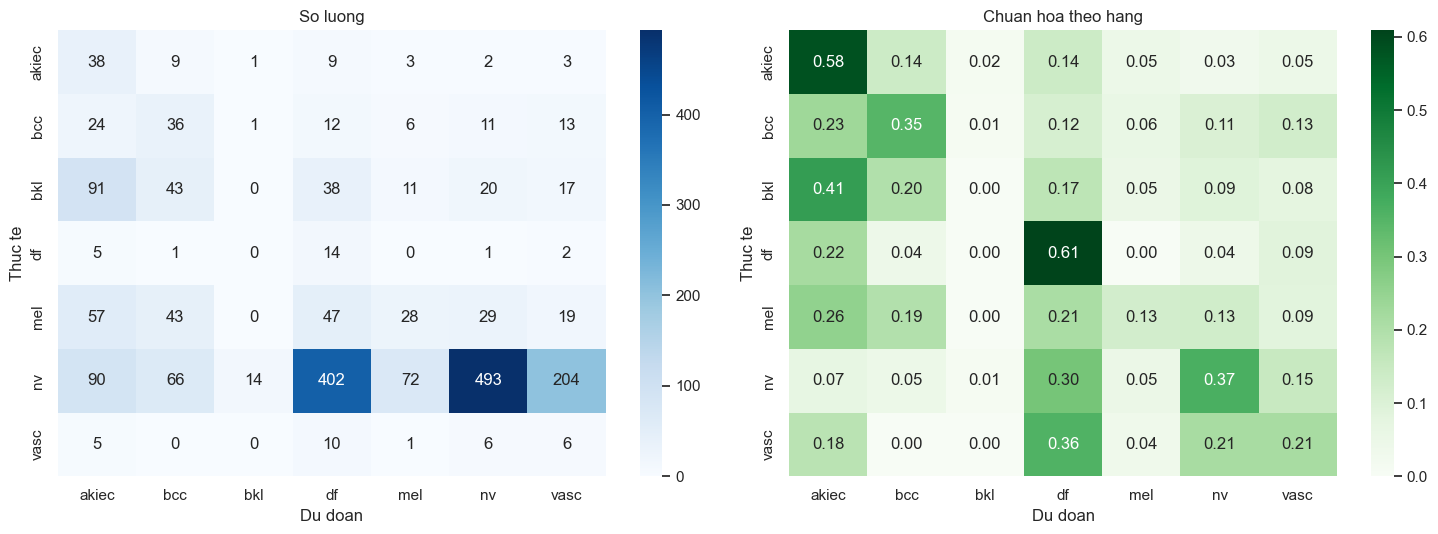

              precision    recall  f1-score   support

       akiec      0.123     0.585     0.203        65
         bcc      0.182     0.350     0.239       103
         bkl      0.000     0.000     0.000       220
          df      0.026     0.609     0.050        23
         mel      0.231     0.126     0.163       223
          nv      0.877     0.368     0.518      1341
        vasc      0.023     0.214     0.041        28

    accuracy                          0.307      2003
   macro avg      0.209     0.321     0.173      2003
weighted avg      0.627     0.307     0.385      2003



In [14]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
cm = confusion_matrix(yte, y_pred_multi)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax[0])
ax[0].set_title('So luong'); ax[0].set_xlabel('Du doan'); ax[0].set_ylabel('Thuc te')
cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=ax[1])
ax[1].set_title('Chuan hoa theo hang'); ax[1].set_xlabel('Du doan'); ax[1].set_ylabel('Thuc te')
plt.tight_layout(); plt.show()

print(classification_report(yte, y_pred_multi, target_names=class_names, digits=3))

Macro-F1 thấp: chỉ với `age`, `sex`, `localization` thì không tách được 7 loại bệnh.
Confusion matrix chuẩn hoá cho thấy nhầm lẫn nhiều giữa các lớp. Cần đặc trưng ảnh
(CNN) để cải thiện.

## 7. So sánh mô hình

              accuracy  macro_F1
model                           
LogReg           0.673     0.613
KNN              0.788     0.619
RandomForest     0.707     0.649
XGBoost          0.794     0.594
SVM              0.693     0.635


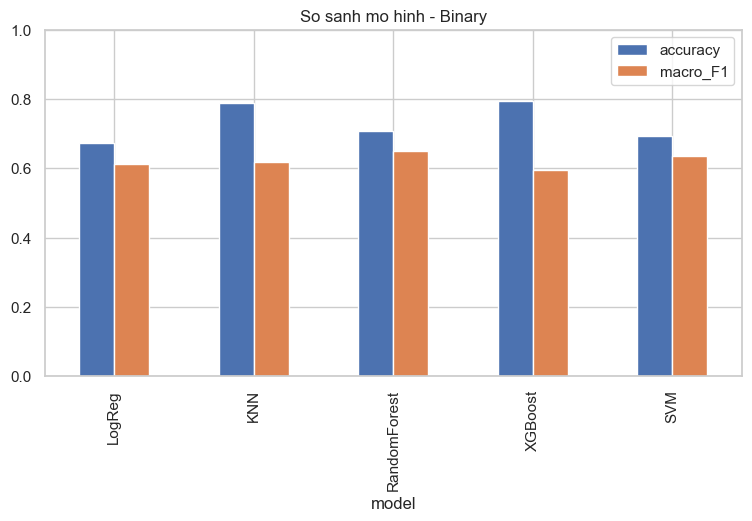

In [15]:
def compare_models(Xtr, ytr, Xte, yte):
    models = {
        'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
        'KNN': KNeighborsClassifier(n_neighbors=15),
        'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                               random_state=RANDOM_STATE, n_jobs=-1),
        'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                 eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE),
        'SVM': SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE),
    }
    rows = []
    for n, m in models.items():
        m.fit(Xtr, ytr)
        p = m.predict(Xte)
        rows.append({'model': n, 'accuracy': round(accuracy_score(yte, p), 3),
                     'macro_F1': round(f1_score(yte, p, average='macro'), 3)})
    return pd.DataFrame(rows).set_index('model')

tr, te = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE, stratify=df['label_binary'])
Xtr, objs = build_features(tr)
Xte, _ = build_features(te, objs)
res_bin = compare_models(Xtr, tr['label_binary'].values, Xte, te['label_binary'].values)
print(res_bin)
res_bin.plot(kind='bar', figsize=(9, 4.5), ylim=(0, 1), title="So sanh mo hinh - Binary"); plt.show()

XGBoost/KNN cho accuracy cao hơn nhưng macro-F1 thấp (thiên về lớp đa số). Trên
macro-F1, SVM ngang RandomForest. Đề yêu cầu SVM và nó cạnh tranh tốt nên dùng SVM.

## 8. Cross-validation & tuning

In [16]:
Xtr, objs = build_features(tr)
Xte, _ = build_features(te, objs)
ytr, yte = tr['label_binary'].values, te['label_binary'].values

param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 0.01]}
grid = GridSearchCV(SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE),
                    param_grid, scoring='f1_macro', cv=5, n_jobs=-1)
grid.fit(Xtr, ytr)
print("Best params:", grid.best_params_)
print("CV macro-F1:", round(grid.best_score_, 3))

best = grid.best_estimator_
p = best.predict(Xte)
print("Test acc:", round(accuracy_score(yte, p), 3),
      "macro-F1:", round(f1_score(yte, p, average='macro'), 3))

cv = cross_val_score(best, Xtr, ytr, cv=5, scoring='f1_macro')
print("5-fold CV:", np.round(cv, 3), "mean:", round(cv.mean(), 3))

Best params: {'C': 10, 'gamma': 0.01}
CV macro-F1: 0.651


Test acc: 0.714 macro-F1: 0.633


5-fold CV: [0.65  0.633 0.652 0.648 0.67 ] mean: 0.651


## 9. Kết luận & hướng mở rộng

- Pipeline đầy đủ: tiền xử lý → SVM (binary + multi-class) → đánh giá → tuning.
- Binary: macro-F1 ~0.63, recall nhóm cần lưu ý ~0.58 — dùng được cho sàng lọc sơ bộ.
- Multi-class: macro-F1 thấp; metadata nhân khẩu học không đủ tách 7 lớp.
- Dữ liệu lệch → theo dõi macro-F1/recall thay vì chỉ accuracy.

Hướng mở rộng:
1. CNN + transfer learning (ResNet/EfficientNet) trên ảnh thô.
2. API (FastAPI/Flask) + giao diện web.
3. Kết hợp metadata với đặc trưng ảnh (multimodal).

Mô hình chỉ hỗ trợ học thuật, không thay thế chẩn đoán y khoa.
